# Notebook 05 — Metric Estimation

**Pipeline:** Adaptive Classical Vision Pipeline for Cut-Edge Detection  
**Step 5:** Detected cut edges → 10 sampling points → metric distances in mm

**Input:**
- Detected lines from `outputs/04_hough/lines.json`
- Calibration data from `outputs/02_rectified/calibration.json`
- Rectified images from `outputs/02_rectified/` (for visualisation only)

**Output:** Metric measurements saved to `outputs/05_metric/measurements.json`

**Key idea:** For each detected cut edge, extract 10 equally spaced sampling
points along the line. Using the px/mm scale factor and the TL QR exterior
corner as origin (both from NB02 calibration), convert pixel coordinates to
metric positions in mm. Then compute the distance from each point to the
bottom border of the table (y = 800 mm).

## 1. Imports and configuration

In [1]:
!pip install opencv-python numpy matplotlib

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────
CALIB_PATH    = Path("outputs/02_rectified/calibration.json")  # from NB02
LINES_PATH    = Path("outputs/04_hough/lines.json")             # from NB04
RECTIFIED_DIR = Path("outputs/02_rectified")                    # for visualisation
OUTPUT_DIR    = Path("outputs/05_metric")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Metric parameters ──────────────────────────────────────────────────────
N_SAMPLE_POINTS = 10    # equally spaced points per cut edge
QR_LEG_MM       = 800.0 # known leg length of QR triangle = bottom border y in mm

# Load data from previous notebooks
with open(CALIB_PATH) as f:
    calibration_data = json.load(f)
with open(LINES_PATH) as f:
    hough_results = json.load(f)

print(f"Calibrated images : {len(calibration_data)}")
print(f"Images with lines : {len(hough_results)}")
print(f"Output dir        : {OUTPUT_DIR.resolve()}")

Calibrated images : 24
Images with lines : 24
Output dir        : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\05_metric


## 2. Pixel to metric conversion

The calibration from NB02 provides:
- `corners_px[0]` = TL QR exterior corner pixel position → metric origin (0, 0)
- `px_per_mm` = pixels per millimetre

Conversion:
```
x_mm = (px - tl_x) / px_per_mm
y_mm = (py - tl_y) / px_per_mm
```
Bottom border of the table is at y = 800 mm (QR triangle leg length).

In [4]:
def px_to_mm(px: float, py: float, calib: dict) -> tuple[float, float]:
    """
    Convert pixel coordinates to metric coordinates (mm).
    Uses calibration data saved by NB02.
    Origin = TL QR exterior corner.
    """
    tl_x  = float(calib['corners_px'][0][0])
    tl_y  = float(calib['corners_px'][0][1])
    scale = float(calib['px_per_mm'])

    return (px - tl_x) / scale, (py - tl_y) / scale

## 3. Sampling points and distance estimation

In [5]:
def sample_edge_points(x1, y1, x2, y2, n=N_SAMPLE_POINTS):
    """Extract n equally spaced points along a line segment."""
    ts = np.linspace(0, 1, n)
    return [(float(x1 + t*(x2-x1)), float(y1 + t*(y2-y1))) for t in ts]


def compute_distances(edge_px: list, calib: dict) -> dict:
    """
    Compute metric positions and distances for one cut edge.

    Parameters
    ----------
    edge_px : [x1, y1, x2, y2] in pixels (from NB04)
    calib   : calibration dict from NB02

    Returns
    -------
    dict with sample points in px and mm, distances to bottom border,
    mean distance, and mean x position of the edge.
    """
    x1, y1, x2, y2 = edge_px
    pts_px = sample_edge_points(x1, y1, x2, y2)
    pts_mm = [px_to_mm(px, py, calib) for px, py in pts_px]

    # Distance from each point to the bottom border (y = QR_LEG_MM)
    distances = [float(QR_LEG_MM - y_mm) for _, y_mm in pts_mm]

    return {
        'sample_points_px': [(round(px,2), round(py,2)) for px,py in pts_px],
        'sample_points_mm': [(round(x,2),  round(y,2))  for x,y  in pts_mm],
        'distances_mm'    : [round(d, 2) for d in distances],
        'mean_dist_mm'    : round(float(np.mean(distances)), 2),
        'edge_x_mm'       : round(float(np.mean([x for x,_ in pts_mm])), 2)
    }

## 4. Full pipeline per image

In [6]:
def process_image(image_name: str) -> dict | None:
    if image_name not in hough_results:
        print(f"  [SKIP] No lines for {image_name}")
        return None

    edges_px = hough_results[image_name]['cut_edges_px']
    if not edges_px:
        print(f"  [WARN] {image_name}: no cut edges detected")
        return None

    calib        = calibration_data[image_name]
    measurements = []
    for i, edge in enumerate(edges_px):
        m = compute_distances(edge, calib)
        m['edge_id'] = i
        measurements.append(m)

    return {
        'image_name'  : image_name,
        'px_per_mm'   : float(calib['px_per_mm']),
        'n_edges'     : len(measurements),
        'measurements': measurements
    }

In [7]:
metric_results = {}

for image_name in calibration_data:
    result = process_image(image_name)
    if result is not None:
        metric_results[image_name] = result
        print(f"  [OK] {image_name:30s}  n_edges={result['n_edges']}")
        for m in result['measurements']:
            print(f"       edge {m['edge_id']}: "
                  f"x={m['edge_x_mm']:7.1f} mm  "
                  f"mean_dist={m['mean_dist_mm']:7.1f} mm")

# Save for NB06
out_path = OUTPUT_DIR / "measurements.json"
with open(out_path, "w") as f:
    json.dump(metric_results, f, indent=2)
print(f"\nSaved to {out_path}")

  [OK] Multimedia_31.jpg               n_edges=5
       edge 0: x=   39.9 mm  mean_dist=  117.2 mm
       edge 1: x=  104.7 mm  mean_dist=  241.8 mm
       edge 2: x=  189.5 mm  mean_dist=  413.6 mm
       edge 3: x=  334.1 mm  mean_dist=  207.6 mm
       edge 4: x=  778.5 mm  mean_dist=  152.1 mm
  [OK] Multimedia_32.jpg               n_edges=3
       edge 0: x=   60.0 mm  mean_dist=  109.9 mm
       edge 1: x=  174.5 mm  mean_dist=  435.0 mm
       edge 2: x=  606.3 mm  mean_dist=  203.0 mm
  [OK] Multimedia_33.jpg               n_edges=4
       edge 0: x=   34.2 mm  mean_dist=  108.5 mm
       edge 1: x=  102.6 mm  mean_dist=  211.3 mm
       edge 2: x=  192.9 mm  mean_dist=  395.8 mm
       edge 3: x=  769.6 mm  mean_dist=  205.2 mm
  [OK] Multimedia_34.jpg               n_edges=3
       edge 0: x=   87.4 mm  mean_dist=  242.1 mm
       edge 1: x=  179.2 mm  mean_dist=  419.8 mm
       edge 2: x=  771.9 mm  mean_dist=  143.4 mm
  [WARN] Multimedia_35.jpg: no cut edges detected
  [W

## 5. Visual inspection

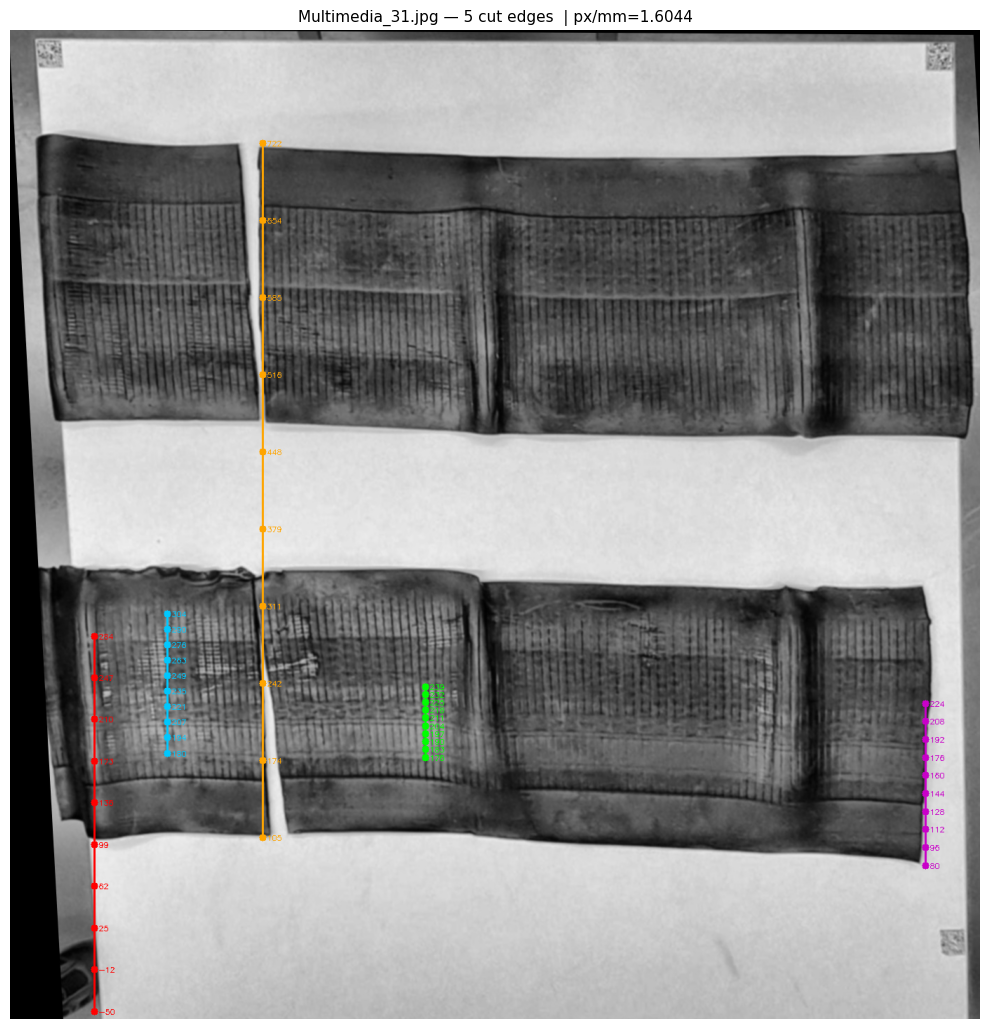

In [8]:
def visualize_measurements(image_name: str):
    result  = metric_results[image_name]
    img     = cv2.imread(str(RECTIFIED_DIR / image_name), cv2.IMREAD_GRAYSCALE)
    overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    colors = [(255,0,0), (0,200,255), (255,165,0), (0,255,0),
              (200,0,200), (255,255,0)]

    for m in result['measurements']:
        color = colors[m['edge_id'] % len(colors)]
        pts   = m['sample_points_px']
        cv2.line(overlay,
                 (int(pts[0][0]),  int(pts[0][1])),
                 (int(pts[-1][0]), int(pts[-1][1])), color, 2)
        for j, (px, py) in enumerate(pts):
            cv2.circle(overlay, (int(px), int(py)), 5, color, -1)
            cv2.putText(overlay, f"{m['distances_mm'][j]:.0f}",
                        (int(px)+6, int(py)+4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.35, color, 1)

    fig, ax = plt.subplots(figsize=(10, 12))
    ax.imshow(overlay)
    ax.set_title(f"{image_name} — {result['n_edges']} cut edges  "
                 f"| px/mm={result['px_per_mm']:.4f}", fontsize=11)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"check_{image_name}", dpi=120)
    plt.show()


if metric_results:
    visualize_measurements(next(iter(metric_results)))

In [9]:
# Visualize a specific image
# visualize_measurements("Multimedia_42.jpg")

## 6. Distance distribution across all images

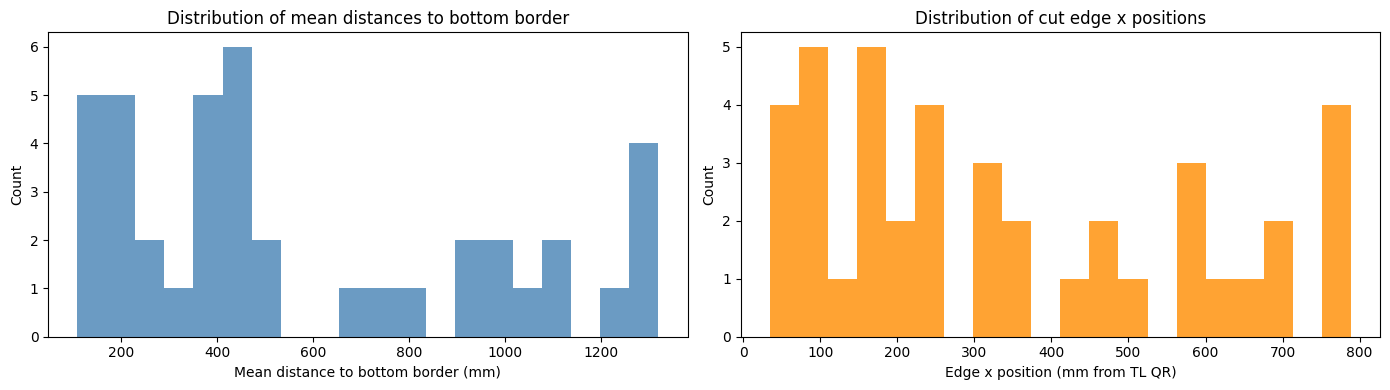

Mean distance to bottom : 574.9 mm
Std  distance to bottom : 389.9 mm
Mean edge x position    : 341.3 mm
Std  edge x position    : 238.7 mm


In [10]:
all_mean_dists  = []
all_x_positions = []

for result in metric_results.values():
    for m in result['measurements']:
        all_mean_dists.append(m['mean_dist_mm'])
        all_x_positions.append(m['edge_x_mm'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(all_mean_dists,  bins=20, color='steelblue',  alpha=0.8)
axes[0].set_xlabel('Mean distance to bottom border (mm)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of mean distances to bottom border')

axes[1].hist(all_x_positions, bins=20, color='darkorange', alpha=0.8)
axes[1].set_xlabel('Edge x position (mm from TL QR)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of cut edge x positions')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'distance_distribution.png', dpi=150)
plt.show()

print(f"Mean distance to bottom : {np.mean(all_mean_dists):.1f} mm")
print(f"Std  distance to bottom : {np.std(all_mean_dists):.1f} mm")
print(f"Mean edge x position    : {np.mean(all_x_positions):.1f} mm")
print(f"Std  edge x position    : {np.std(all_x_positions):.1f} mm")

## 7. Summary

| Step | Operation | Detail |
|------|-----------|--------|
| 5a | Load lines | from `outputs/04_hough/lines.json` |
| 5b | Load calibration | from `outputs/02_rectified/calibration.json` |
| 5c | 10 sampling points | equally spaced along each cut edge |
| 5d | px → mm conversion | TL QR corner as origin, `px_per_mm` scale |
| 5e | Distance to bottom | `dist = 800 mm - y_mm` |

**Output folder:** `outputs/05_metric/`  
**Measurements file:** `outputs/05_metric/measurements.json`  
**Used by:** NB06  
**Next notebook:** `06_evaluation.ipynb` — reads all previous outputs, no reprocessing